In [1]:
# import csv
import pandas as pd
import numpy as np
from pathlib import Path  
from collections import deque
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["figure.figsize"] = 6,6
plt.rcParams["font.size"] = 14
plt.rcParams["axes.grid"] = True

In [3]:
# filename = Path("log_data")/"imu_log_2026-08-23_00-20-04.csv" 
filename = Path("log_data")/"imu_log_2026-08-28_02-33-36.csv"
print(filename)

log_data\imu_log_2026-08-28_02-33-36.csv


In [4]:
# get rid of spaces in header of origin .csv 
new_header =  ["time_ms", 
               "acc_x", "acc_y", "acc_z", 
               "gyro_x", "gyro_y", "gyro_z", 
               "mag_x", "mag_y", "mag_z"]
df = pd.read_csv(filename,
                 header=0, 
                 names = new_header)
print(df.shape)
df.head(5)

(2997, 10)


,time_ms,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z
0,41295,-0.158,-0.043,1.022,1.481,1.481,-0.397,-28.65,15.15,27.60
1,41315,-0.160,-0.045,1.024,1.298,1.466,-0.107,-27.60,15.60,28.95
2,41335,-0.160,-0.042,1.023,1.221,1.344,-0.229,-28.65,15.60,27.15
3,41355,-0.158,-0.043,1.022,1.267,1.237,-0.198,-28.80,14.25,28.05
4,41375,-0.161,-0.042,1.021,1.237,1.389,-0.244,-28.80,15.00,27.30


In [5]:
print(df.columns)
print(df.index)
# df.loc[:, ['acc_x','acc_y', 'acc_z',  "time_ms"]].head()

Index(['time_ms', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z',
       'mag_x', 'mag_y', 'mag_z'],
      dtype='str')
RangeIndex(start=0, stop=2997, step=1)


### Base statistics for raw meas

In [6]:
df.describe()

,time_ms,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z
count,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000
mean,71255.000000,-0.118464,-0.070945,0.242456,0.395251,1.677059,2.431136,-36.057207,9.345045,13.608959
std,17306.074078,0.449977,0.547385,0.684011,53.168762,40.340972,31.524254,10.302680,11.568908,12.624596
min,41295.000000,-1.575000,-1.146000,-1.094000,-172.748000,-186.550000,-305.603000,-60.600000,-16.950000,-12.450000
25%,56275.000000,-0.365000,-0.396000,-0.171000,-21.252000,-10.000000,-6.885000,-43.500000,1.800000,5.700000
50%,71255.000000,0.012000,-0.089000,0.252000,1.206000,1.450000,-0.183000,-38.700000,7.500000,15.300000
75%,86235.000000,0.138000,0.195000,0.938000,17.328000,18.947000,10.702000,-27.300000,17.400000,25.350000
max,101215.000000,1.058000,1.112000,2.000000,177.969000,191.008000,144.763000,-16.500000,37.350000,32.550000


(2997, 3)
   acc_x  acc_y  acc_z
0 -0.158 -0.043  1.022
1 -0.160 -0.045  1.024
2 -0.160 -0.042  1.023
3 -0.158 -0.043  1.022
4 -0.161 -0.042  1.021


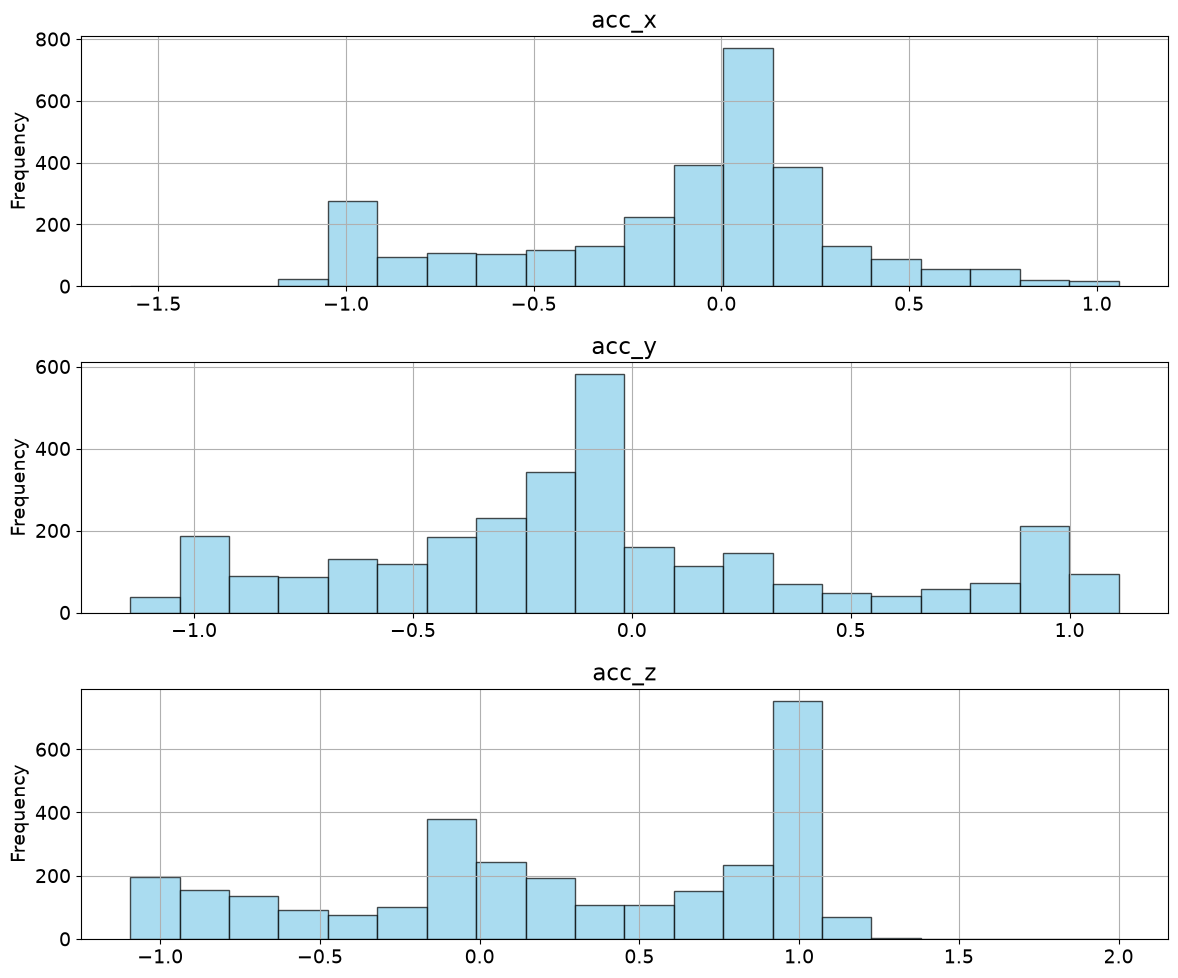

In [7]:
acc_meas = df.loc[:, ["acc_x", "acc_y", "acc_z"]]
print(acc_meas.shape)
print(acc_meas.head(5))

fig, axes = plt.subplots(3,1, figsize=(12, 10))
for ind, column in enumerate(acc_meas.columns):
    axes[ind].hist(acc_meas[column], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[ind].set_title(f'{column}')
    axes[ind].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

(2997, 3)
   gyro_x  gyro_y  gyro_z
0   1.481   1.481  -0.397
1   1.298   1.466  -0.107
2   1.221   1.344  -0.229
3   1.267   1.237  -0.198
4   1.237   1.389  -0.244


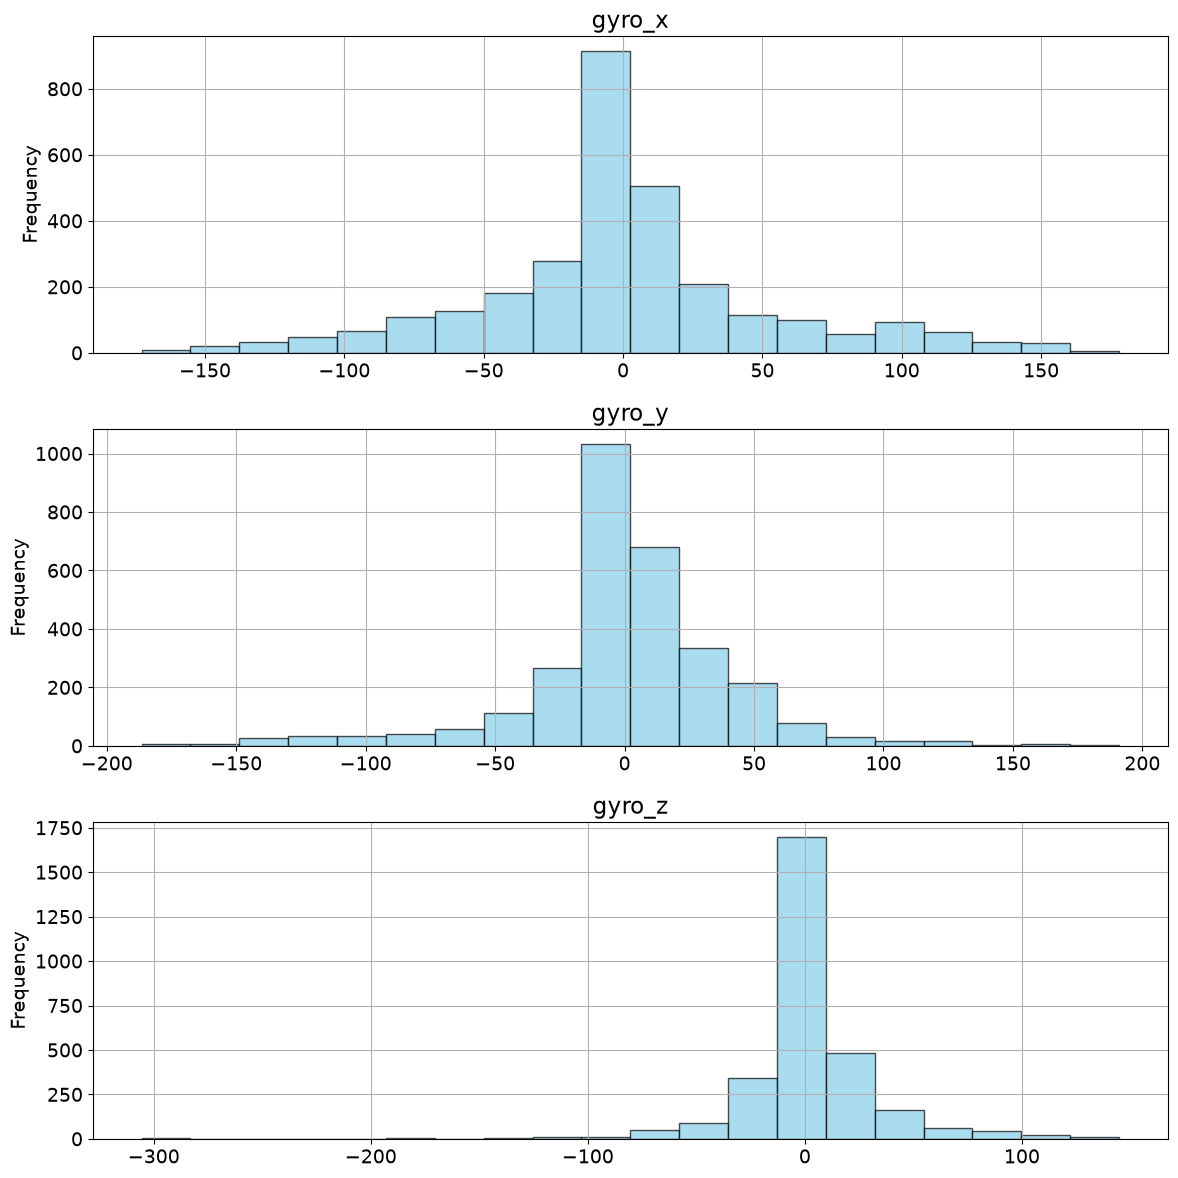

In [8]:
gyro_meas = df.loc[:, ["gyro_x", "gyro_y", "gyro_z"]]
print(gyro_meas.shape)
print(gyro_meas.head(5))

fig, axes = plt.subplots(3,1, figsize=(12, 12))
for ind, column in enumerate(gyro_meas.columns):
    axes[ind].hist(gyro_meas[column], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[ind].set_title(f'{column}')
    axes[ind].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

(2997, 3)
   mag_x  mag_y  mag_z
0 -28.65  15.15  27.60
1 -27.60  15.60  28.95
2 -28.65  15.60  27.15
3 -28.80  14.25  28.05
4 -28.80  15.00  27.30


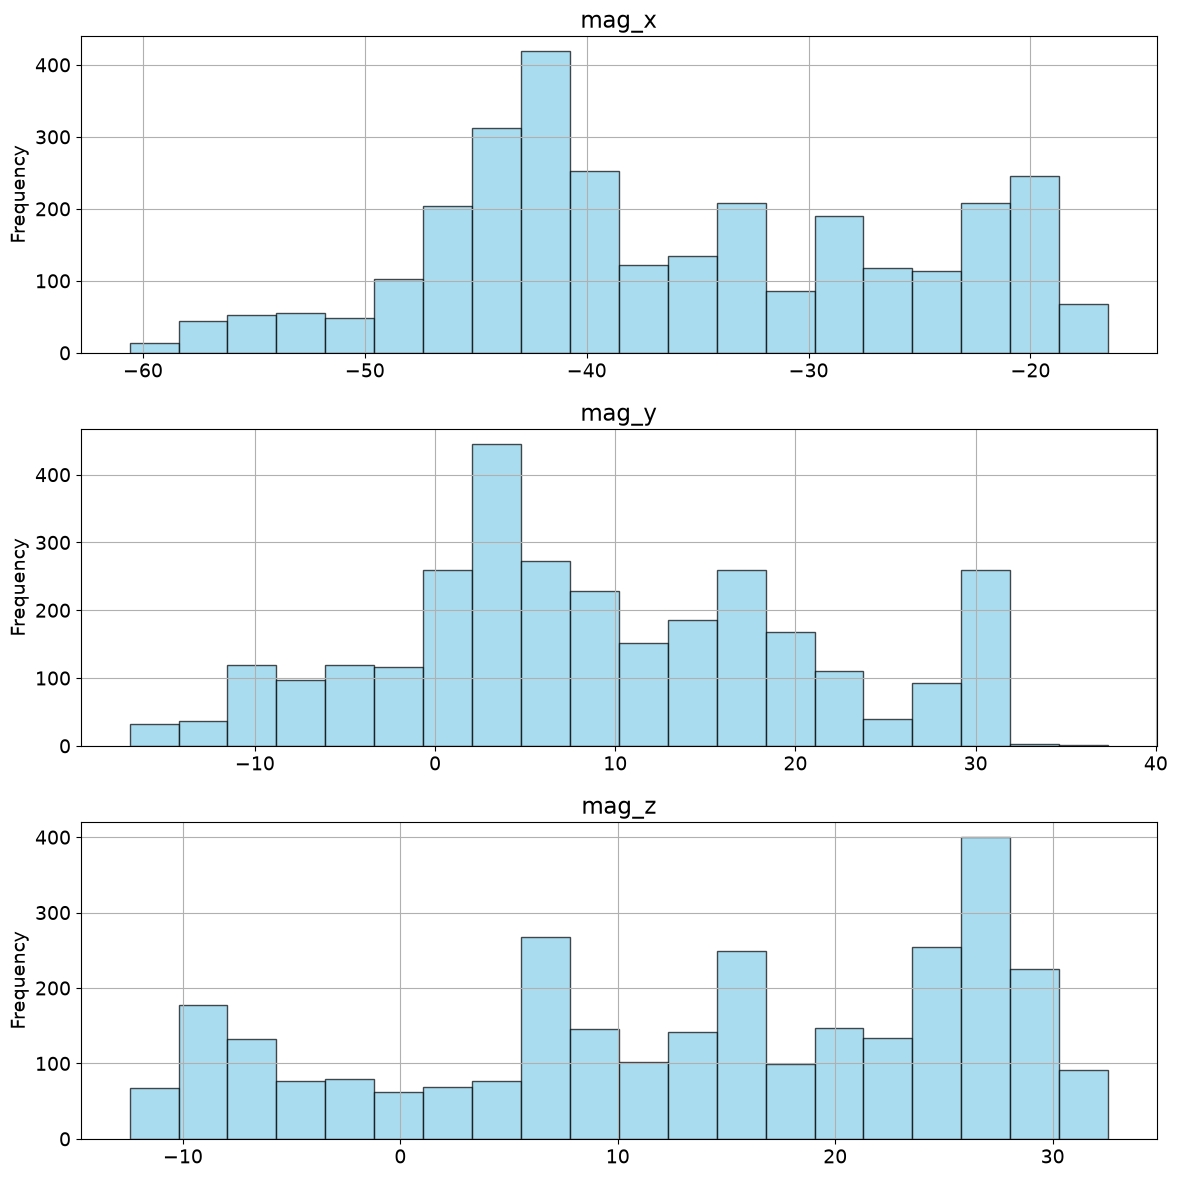

In [9]:
mag_meas = df.loc[:, ["mag_x", "mag_y", "mag_z"]]
print(mag_meas.shape)
print(mag_meas.head(5))

fig, axes = plt.subplots(3,1, figsize=(12, 12))
for ind, column in enumerate(mag_meas.columns):
    axes[ind].hist(mag_meas[column], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[ind].set_title(f'{column}')
    axes[ind].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### MAD (Mean Absolute Deviation) calculation (for each axis):
$$MAD_i  = 1.4826 * median (|meas_i - median_{meas}|)$$

*outter median - median of deviation  
*median_meas - median of all measurements for each axis  
*meas_i - measurements along axis i

In [10]:
def hampel_filtration(meas: pd.DataFrame):
    # calc median for each axis
    meas_median = meas.median()
    # absolute deviation from median value
    abs_dev = abs(meas - meas_median)
    # MAD 
    MAD = 1.4826 * abs_dev.median()
    # threshold ~ 3sigma?
    T = 3 * MAD
    # filter only valid meas: if there is any axis meas that is greater then thres -> row of meas (x,y,z) is banned 
    mask =  abs_dev < T
    #filter out rows if any value is false
    return meas[mask.all(axis=1)] #axis = 1 -> horizontally

filtered_acc_meas = hampel_filtration(acc_meas)
filtered_gyro_meas = hampel_filtration(gyro_meas)
filtered_mag_meas    = hampel_filtration(mag_meas)

In [11]:
# display changed(?) stat
filtered_acc_meas.columns = [f"filtered_{col}" for col in acc_meas.columns]
print(acc_meas.describe(),end='\n\n')
print(filtered_acc_meas.describe())
    


             acc_x        acc_y        acc_z
count  2997.000000  2997.000000  2997.000000
mean     -0.118464    -0.070945     0.242456
std       0.449977     0.547385     0.684011
min      -1.575000    -1.146000    -1.094000
25%      -0.365000    -0.396000    -0.171000
50%       0.012000    -0.089000     0.252000
75%       0.138000     0.195000     0.938000
max       1.058000     1.112000     2.000000

       filtered_acc_x  filtered_acc_y  filtered_acc_z
count     2543.000000     2543.000000     2543.000000
mean         0.003280       -0.049373        0.269295
std          0.300472        0.584359        0.730206
min         -0.760000       -1.146000       -1.094000
25%         -0.146500       -0.424000       -0.325500
50%          0.052000       -0.080000        0.414000
75%          0.151000        0.264000        0.964000
max          0.784000        1.112000        2.000000


### Calculate mean value for each axis

In [12]:
mean_acc_meas = filtered_acc_meas.mean()
mean_gyro_meas = filtered_gyro_meas.mean()
mean_mag_meas = filtered_mag_meas.mean()
# print("Mean accelerometer's value (g) per axis: ", mean_acc_meas.filtered_acc_x, mean_acc_meas.filtered_acc_y, mean_acc_meas.filtered_acc_z)
print(f"Mean accelerometer's value (G): \n\tX: {mean_acc_meas.iloc[0]:8.4f}\t Y: {mean_acc_meas.iloc[1]:8.4f}\t Z:{mean_acc_meas.iloc[2]:8.4f}")
print(f"Mean gyros's value (dps): \n\tX: {mean_gyro_meas.iloc[0]:8.4f}\t Y: {mean_gyro_meas.iloc[1]:8.4f}\t Z:{mean_gyro_meas.iloc[2]:8.4f}")
print(f"Mean mag's value (usT): \n\tX:  {mean_mag_meas.iloc[0]:8.4f}\t Y: {mean_mag_meas.iloc[1]:8.4f}\t Z:{mean_mag_meas.iloc[2]:8.4f}")

Mean accelerometer's value (G): 
	X:   0.0033	 Y:  -0.0494	 Z:  0.2693
Mean gyros's value (dps): 
	X:  -1.8405	 Y:   4.0563	 Z:  0.5231
Mean mag's value (usT): 
	X:  -36.0572	 Y:   9.3450	 Z: 13.6090


In [13]:
# Check norm of accel  
print(f"Accel gravity norm: {np.linalg.norm(mean_acc_meas.values):.5f}") #shoul be ~1

Accel gravity norm: 0.27380


### Save mean values to csv 

In [14]:
# df.to_csv
mag_meas.columns

Index(['mag_x', 'mag_y', 'mag_z'], dtype='str')

### Hist comparition after outlier rejection

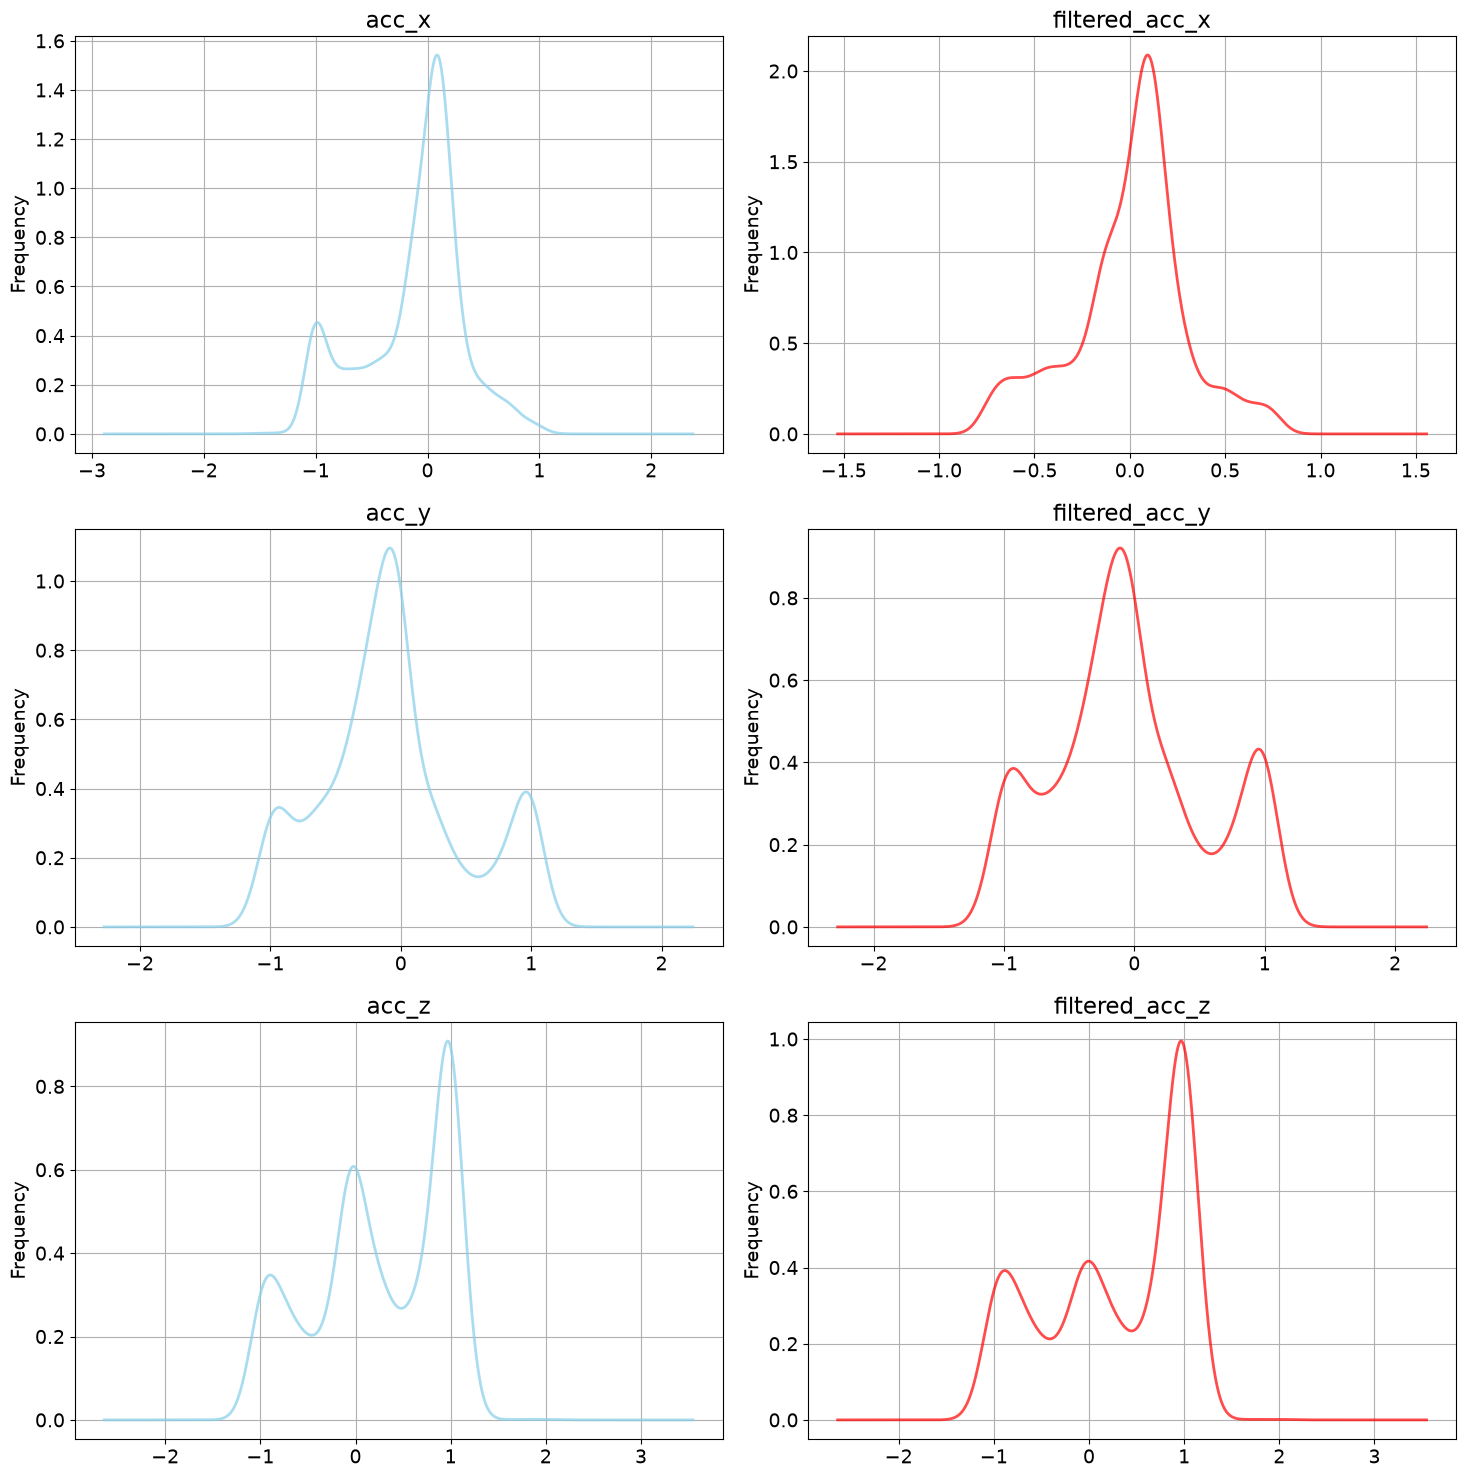

In [15]:
fig, axes = plt.subplots(3,2, figsize=(15, 15), squeeze=False)
for ind, (origin_col, filt_col) in enumerate(zip(acc_meas.columns, filtered_acc_meas.columns)):
    acc_meas[origin_col].plot.kde(ax=axes[ind][0], color='skyblue', linewidth=2, alpha=0.7) #scipy should be installed!
    axes[ind][0].set_title(f'{origin_col}')
    axes[ind][0].set_ylabel('Frequency')
    filtered_acc_meas[filt_col].plot.kde(ax=axes[ind][1], color='red', linewidth=2, alpha=0.7)
    axes[ind][1].set_title(f'{filt_col}')
    axes[ind][1].set_ylabel('Frequency') 
plt.tight_layout()
plt.show()

### 3D plots of accel and magnet measuremens to discover form of gavitation and magnet field

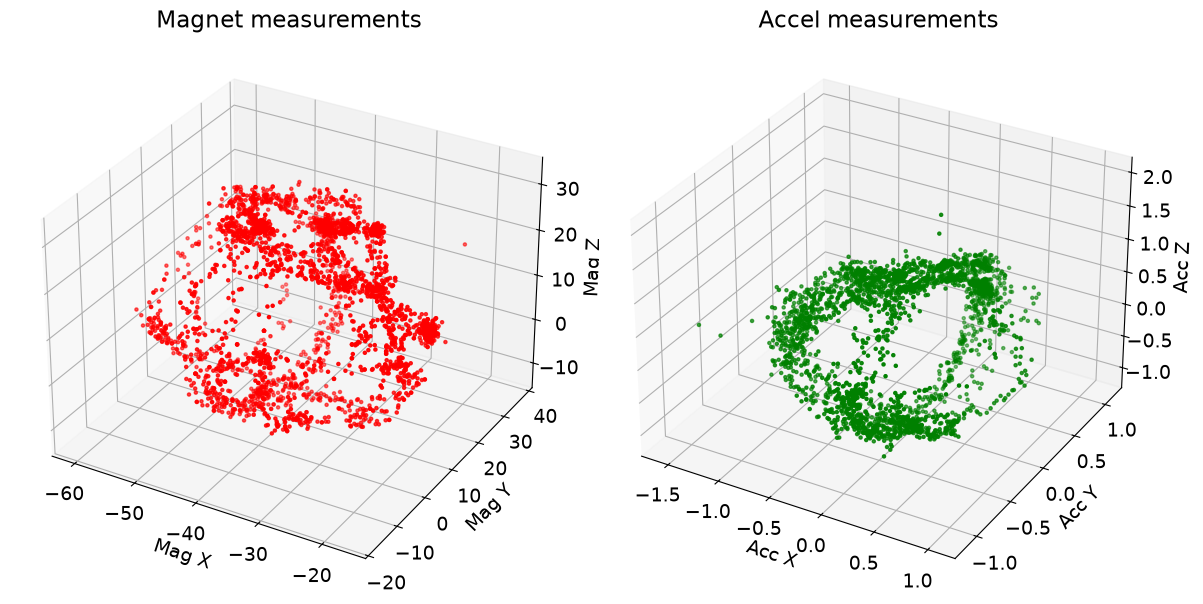

In [16]:
fig = plt.figure(figsize=(12,6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# magnetmeter
ax1.scatter(mag_meas["mag_x"], mag_meas["mag_y"], mag_meas["mag_z"],  c='red', s=5)
ax1.set_xlabel('Mag X')
ax1.set_ylabel('Mag Y')
ax1.set_zlabel('Mag Z')
ax1.set_title('Magnet measurements')
# ax1.set_aspect('equal')

# accelerometer acc_meas["acc_x"], acc_meas["acc_y"], acc_meas["acc_z"] gyro_meas["gyro_x"], gyro_meas["gyro_y"], gyro_meas["gyro_z"]
ax2.scatter(acc_meas["acc_x"], acc_meas["acc_y"], acc_meas["acc_z"], c='green', s=5)
ax2.set_xlabel('Acc X')
ax2.set_ylabel('Acc Y')
ax2.set_zlabel('Acc Z')
ax2.set_title('Accel measurements')
# ax2.set_aspect('equal')

plt.subplots_adjust(wspace=0.7)  
plt.tight_layout()
plt.show()